In [36]:
from pathlib import Path
import pandas as pd
from src.utils import read_obs
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [57]:
obs = read_obs("/root/capsule/data/combined_adata/CaH_Xenium.2026-01-07.h5ad")

In [91]:
obs['Neighborhood'].astype(str).str.replace(f"_Neighborhood", "").value_counts()

Neighborhood
OPC-Oligo     359356
Vascular      304680
LGE           272628
Unknown       232772
Astro-Epen    216872
Immune        126451
MGE            26619
CGE             2097
LSX                2
Name: count, dtype: int64

In [66]:
obs.groupby("barcode")[level].value_counts().unstack("Neighborhood").min()

/tmp/ipykernel_45070/3535581523.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby("barcode")[level].value_counts().unstack("Neighborhood").min()


Neighborhood
Astro-Epen_Neighborhood    2983
CGE_Neighborhood             26
Immune_Neighborhood        1630
LGE_Neighborhood           3434
LSX _Neighborhood             0
MGE_Neighborhood            417
OPC-Oligo_Neighborhood     4494
Unknown                    2445
Vascular_Neighborhood      4198
dtype: int64

In [68]:
obs = read_obs("/root/capsule/data/combined_adata/CaH_Xenium.2026-01-07.h5ad")
# obs[["Neighborhood", "Subclass", "Supertype"]] = obs[["Neighborhood", "Subclass", "Supertype"]].astype("str").map(lambda x: "_".join(x.split("_")[:-1])), 
cells_to_remove = []
for level in ["Neighborhood", "Subclass", "Supertype"]:
    obs[level] = obs['Neighborhood'].astype(str).replace(f"_{level}", "")
    level_counts = obs.groupby("barcode")[level].value_counts().unstack(level).min()
    celltypes = level_counts[level_counts < 10].index.tolist()
    cells_to_remove += celltypes

/tmp/ipykernel_45070/1347605591.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_counts = obs.groupby("barcode")[level].value_counts().unstack(level).min()
/tmp/ipykernel_45070/1347605591.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_counts = obs.groupby("barcode")[level].value_counts().unstack(level).min()
/tmp/ipykernel_45070/1347605591.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_coun

# pTau neighborhood enrichment

In [69]:
stat_dir = Path("/root/capsule/data/20251208_neighborhood_enrichment/pTau_neighborhood_enrichment")
dfs  = []
radius2bin = {'5.0':'[0,5]', 
              '10.0':'(5, 10]',
              '15.0':'(10, 15]',
              '20.0':'(15, 20]',
              '25.0':'(20, 25]',
              '30.0':'(25, 30]',
              '35.0':'(30, 35]',
              '40.0':'(35, 40]',
             }
for path in stat_dir.glob("**/neighborhood_stats_*.csv"):
    radius = path.stem.split("_")[-1]
    level = path.stem.split("_")[-4]
    df = pd.read_csv(path).set_index(["source", "target"])
    df["barcode"] = int(path.parent.name.split("_")[0])
    df['radius'] = float(radius)
    df['Distance Bins'] =  radius2bin[radius]
    df["level"] = level
    dfs.append(df)
stat_df = pd.concat(dfs)
stat_df

,,radius_bins,observed,mean_sim,std_sim,z,p_value,adj_p_value,barcode,radius,Distance Bins,level
source,target,,,,,,,,,,,
Oligodendrocyte,Oligodendrocyte,141.176471,5976,4952.960317,102.831987,9.948652,0.000000e+00,0.000000e+00,1417643362,30.0,"(25, 30]",Subclass
Tau,Oligodendrocyte,141.176471,5753,5157.483135,74.152408,8.030985,8.881784e-16,5.832372e-14,1417643362,30.0,"(25, 30]",Subclass
Oligodendrocyte,Tau,141.176471,5753,5157.483135,74.152408,8.030985,8.881784e-16,5.832372e-14,1417643362,30.0,"(25, 30]",Subclass
VLMC,VLMC,141.176471,574,399.684524,28.156600,6.190928,5.981111e-10,2.945697e-08,1417643362,30.0,"(25, 30]",Subclass
Ependymal,Microglia-PVM,141.176471,30,11.133929,3.493634,5.400128,6.659352e-08,2.186487e-06,1417643362,30.0,"(25, 30]",Subclass
...,...,...,...,...,...,...,...,...,...,...,...,...
STRd D1 Striosome MSN,STR TAC3-PLPP4 GABA,47.058824,6,5.972222,2.353814,0.011801,9.905842e-01,9.936066e-01,1417643954,10.0,"(5, 10]",Supertype
STR TAC3-PLPP4 GABA,Micro-PVM_3-SEAAD,47.058824,1,1.001984,1.043253,-0.001902,9.984825e-01,9.990047e-01,1417643954,10.0,"(5, 10]",Supertype
Micro-PVM_3-SEAAD,STR TAC3-PLPP4 GABA,47.058824,1,1.001984,1.043253,-0.001902,9.984825e-01,9.990047e-01,1417643954,10.0,"(5, 10]",Supertype


In [70]:
stat_df["Neighborhood_Enrichment"] = 0
stat_df = stat_df.reset_index()
stat_df.loc[(stat_df["adj_p_value"] < 0.05), "Neighborhood_Enrichment"] = stat_df.loc[stat_df["adj_p_value"] < 0.01, "z"]

/tmp/ipykernel_45070/2729194831.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[9.94865231 8.03098482 8.03098482 ...        nan        nan        nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  stat_df.loc[(stat_df["adj_p_value"] < 0.05), "Neighborhood_Enrichment"] = stat_df.loc[stat_df["adj_p_value"] < 0.01, "z"]


In [71]:
df = stat_df.copy()

In [72]:
df = df[~df["source"].isin(cells_to_remove) & ~df["target"].isin(cells_to_remove)]

# Figure 4D: Neighborhood enrichment between pTau+ neurons and other cell types

In [73]:
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    ax = sns.barplot(data = df[ (df["source"] == "Tau") & (~df["target"].isin(["Tau", "Unknown"])) & (df['level'] == "Subclass")].sort_values("source"), x = "target", y = "Neighborhood_Enrichment", hue = "Distance Bins", palette = "magma", hue_order = radius2bin.values(),  err_kws={'linewidth': 0.5})
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", ax = ax, color = "black", s = 6)
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", hue = "radius", ax = ax)
    plt.xticks(rotation = 45, ha='right')
    plt.ylabel("Neighborhood Enrichment - pTau")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = r"Distance Bins")
    # for bar in ax.patches:
    #     # Modify outline properties for each bar
    #     bar.set_edgecolor('black')  # Set the outline color
    #     bar.set_linewidth(1.5)      # Set the outline width
    # plt.savefig(
    # f'/scratch/Figure6_neighborhood_enrichment_pTau.svg',
    # bbox_inches='tight',
    # )    
    plt.show()

# Supplemental Figure 3C pTau+ and other microglia supertypes

In [74]:
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    sns.barplot(data = df[ (df["source"] == "Tau") & (df["target"].str.startswith("Micro")) & (df['level'] == "Supertype")].sort_values("source"), x = "target", y = "Neighborhood_Enrichment", hue = "Distance Bins", palette = "magma", hue_order = radius2bin.values(),  err_kws={'linewidth': 0.5})
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", ax = ax, color = "black", s = 6)
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", hue = "radius", ax = ax)
    plt.xticks(rotation = 45, ha='right')
    plt.ylabel("Neighborhood Enrichment - pTau")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = r"Distance Bins - $\mu m$")
    # for bar in ax.patches:
    #     # Modify outline properties for each bar
    #     bar.set_edgecolor('black')  # Set the outline color
    #     bar.set_linewidth(1.5)      # Set the outline width
    # plt.savefig(
    # f'/scratch/Supplemental3_neighborhood_enrichment_pTau_micro.svg',
    # bbox_inches='tight',
    # )    
    plt.show()

# Abeta neighborhood enrichment

In [75]:
stat_dir = Path("/data/20251208_neighborhood_enrichment/abeta_neighborhood_enrichment/")
dfs  = []
radius2bin = {'5.0':'[0,5]', 
              '10.0':'(5, 10]',
              '15.0':'(10, 15]',
              '20.0':'(15, 20]',
              '25.0':'(20, 25]',
              '30.0':'(25, 30]',
              '35.0':'(30, 35]',
              '40.0':'(35, 40]',
             }
for path in stat_dir.glob("**/neighborhood_stats_*.csv"):
        radius = path.stem.split("_")[-1]
        level = path.stem.split("_")[-4]
        df = pd.read_csv(path).set_index(["source", "target"])
        df["barcode"] = int(path.parent.name.split("_")[0])
        df['radius'] = float(radius)
        df['Distance Bins'] =  radius2bin[radius]
        df["level"] = level
        dfs.append(df)
stat_df = pd.concat(dfs)
stat_df

,,radius_bins,observed,mean_sim,std_sim,z,p_value,adj_p_value,barcode,radius,Distance Bins,level
source,target,,,,,,,,,,,
Oligodendrocyte,Oligodendrocyte,141.176471,5976,4947.861111,99.508247,10.332198,0.000000e+00,0.000000e+00,1417643362,30.0,"(25, 30]",Subclass
VLMC,VLMC,141.176471,574,400.603175,28.877876,6.004487,1.919381e-09,1.890591e-07,1417643362,30.0,"(25, 30]",Subclass
Ependymal,Microglia-PVM,141.176471,30,10.971230,3.547684,5.363716,8.152714e-08,4.015212e-06,1417643362,30.0,"(25, 30]",Subclass
Microglia-PVM,Ependymal,141.176471,30,10.971230,3.547684,5.363716,8.152714e-08,4.015212e-06,1417643362,30.0,"(25, 30]",Subclass
Ependymal,Ependymal,141.176471,50,20.152778,6.487975,4.600391,4.216981e-06,1.661490e-04,1417643362,30.0,"(25, 30]",Subclass
...,...,...,...,...,...,...,...,...,...,...,...,...
Micro-PVM_2,VLMC_1,47.058824,37,36.852183,6.083087,0.024300,9.806135e-01,9.821315e-01,1417643954,10.0,"(5, 10]",Supertype
STR FS PTHLH-PVALB GABA,SMC-SEAAD,47.058824,3,3.043651,1.798178,-0.024275,9.806332e-01,9.821315e-01,1417643954,10.0,"(5, 10]",Supertype
SMC-SEAAD,STR FS PTHLH-PVALB GABA,47.058824,3,3.043651,1.798178,-0.024275,9.806332e-01,9.821315e-01,1417643954,10.0,"(5, 10]",Supertype


In [76]:
stat_df["Neighborhood_Enrichment"] = 0
stat_df = stat_df.reset_index()
stat_df.loc[(stat_df["adj_p_value"] < 0.05), "Neighborhood_Enrichment"] = stat_df.loc[stat_df["adj_p_value"] < 0.05, "z"]

/tmp/ipykernel_45070/1315703484.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[10.33219773  6.00448671  5.3637158  ...  2.52605495  2.52399938
  2.52399938]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  stat_df.loc[(stat_df["adj_p_value"] < 0.05), "Neighborhood_Enrichment"] = stat_df.loc[stat_df["adj_p_value"] < 0.05, "z"]


In [77]:
df = stat_df.reset_index()

In [78]:
df = df[~df["source"].isin(cells_to_remove) & ~df["target"].isin(cells_to_remove)]

# Figure 4H

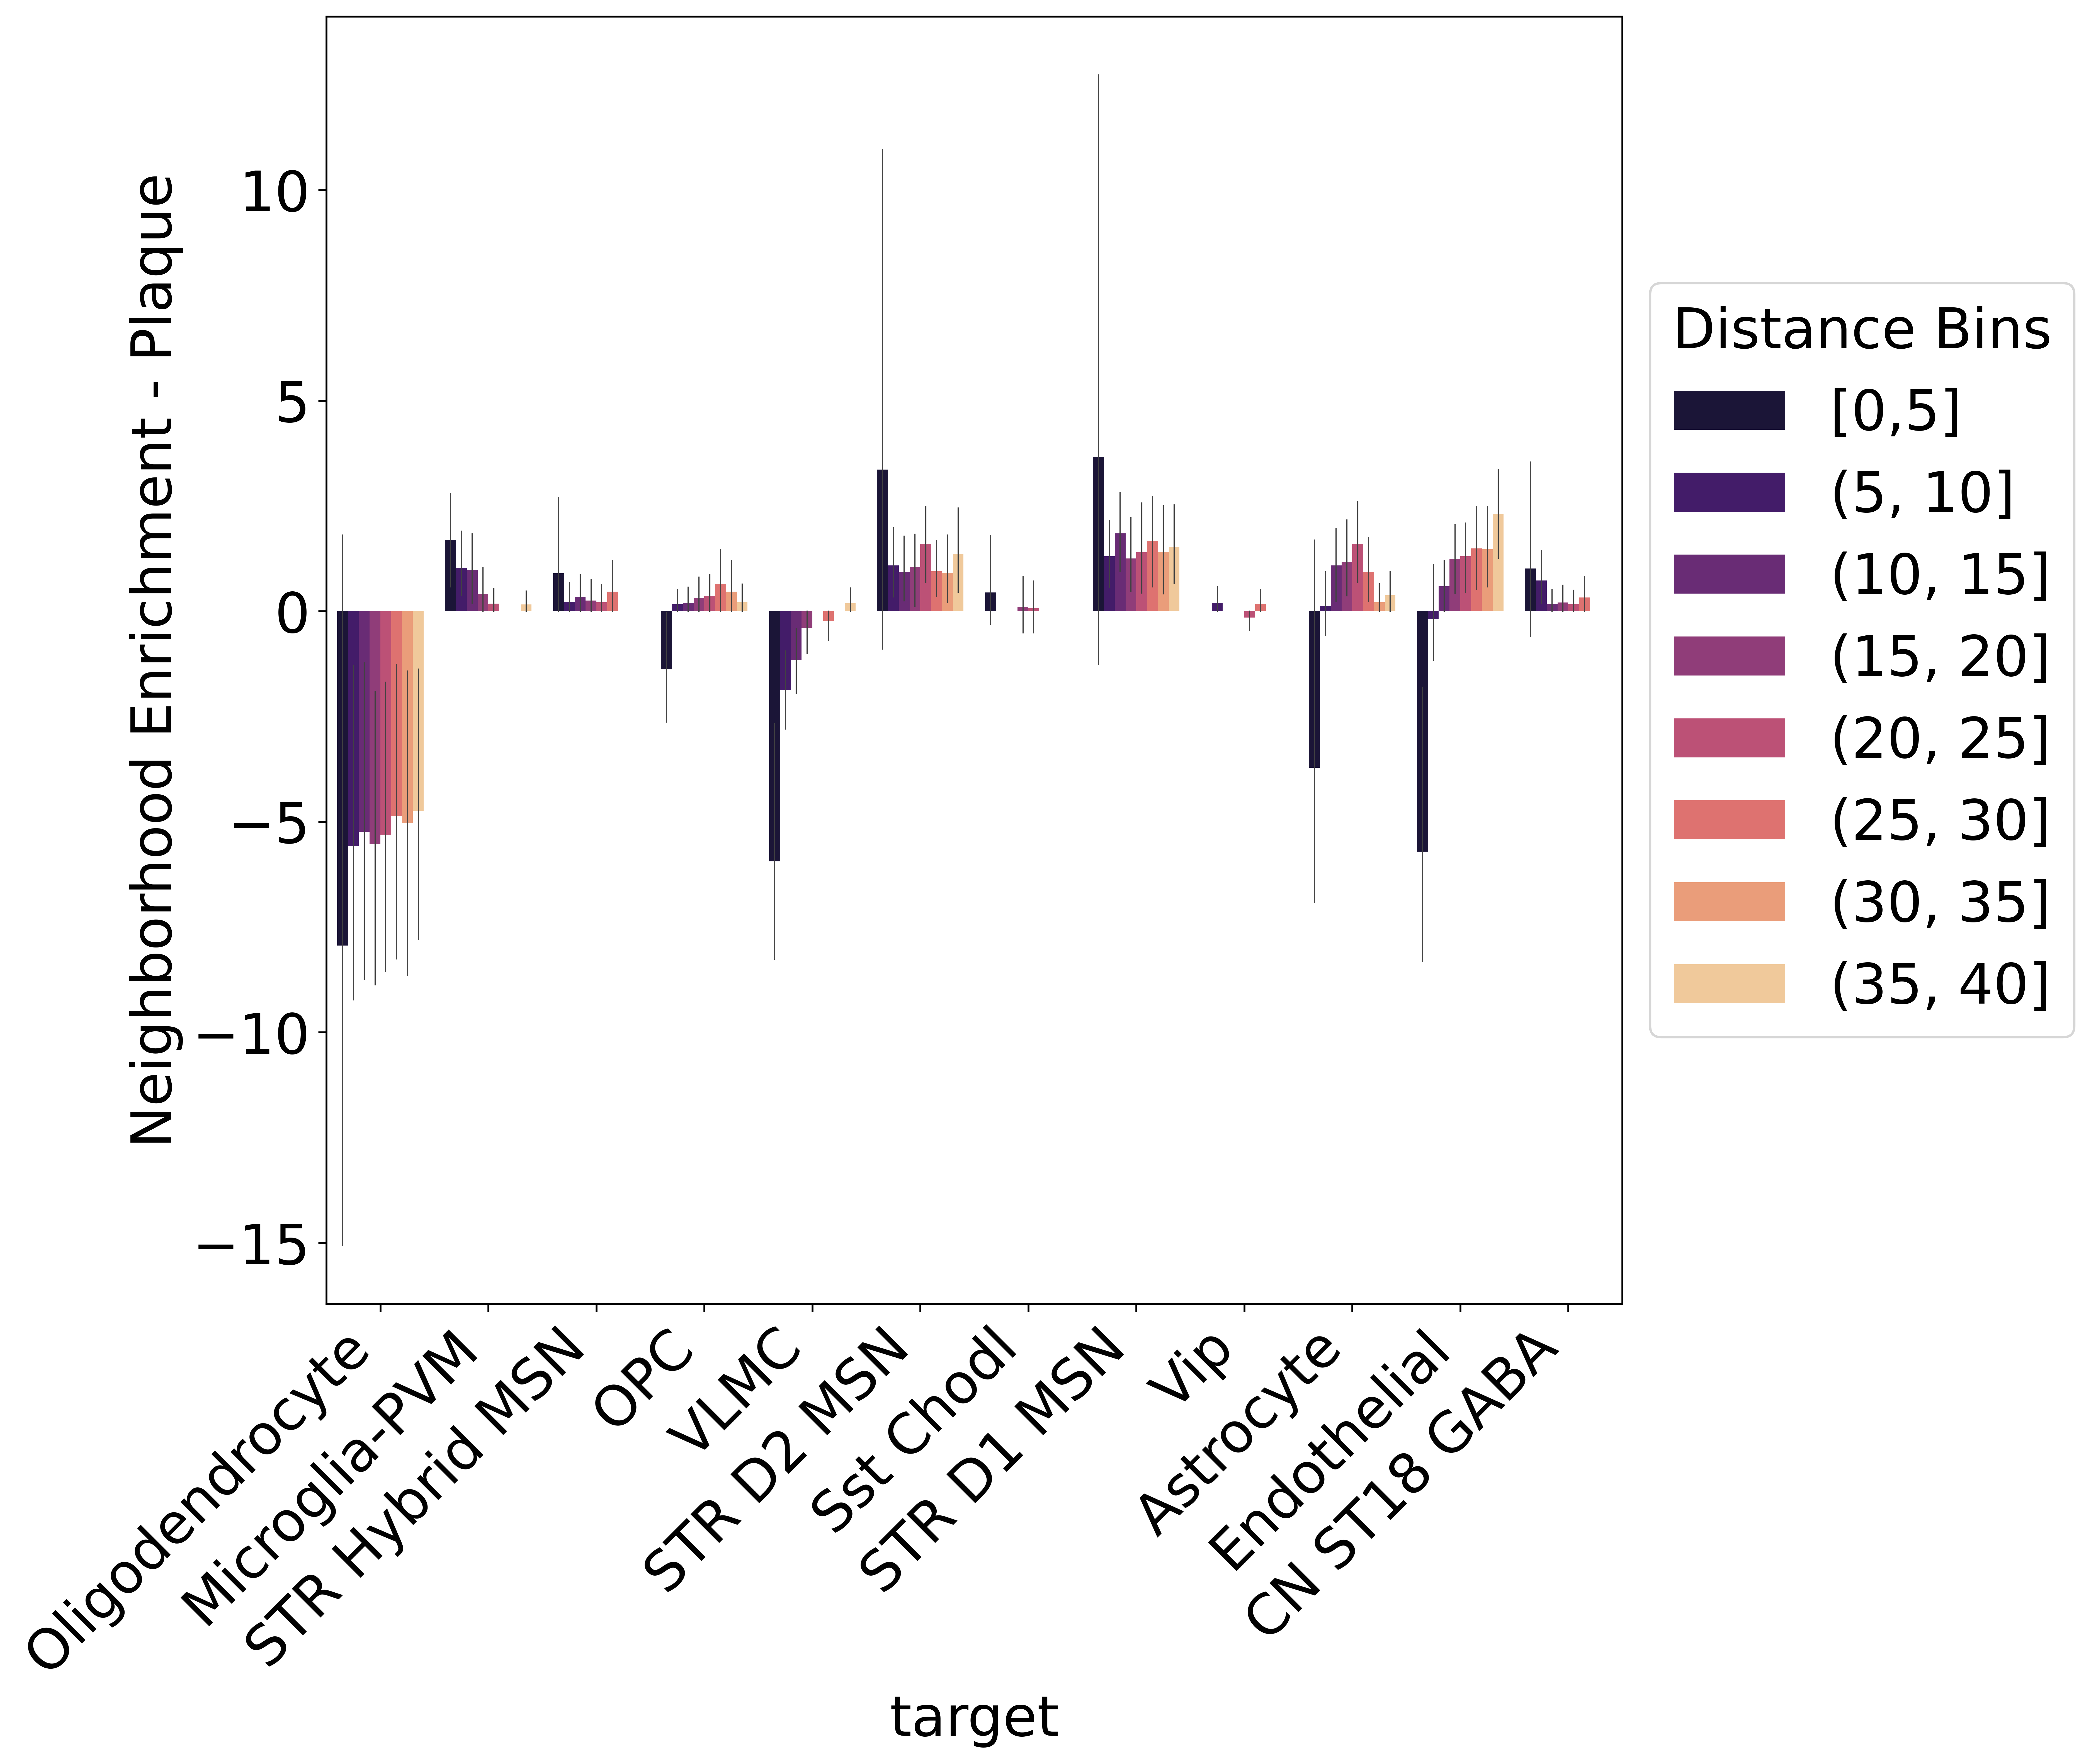

In [79]:
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    order = ["Oligodendrocyte", "Microglia-PVM", "STR Hybrid MSN", "OPC", "VLMC", "STR D2 MSN", "Sst Chodl", "STR D1 MSN", "Vip", "Astrocyte", "Endothelial", "CN ST18 GABA"]
    plot_df = df[ (df["source"] == "Plaque") & (~df["target"].isin(["Plaque", "Unknown"])) & (df['level'] == "Subclass")]
    # assert set(order) == set(plot_df["target"]), f"Not found: {list(set(order) - set(plot_df["target"]))}"
    sns.barplot(data = df[ (df["source"] == "Plaque") & (~df["target"].isin(["Plaque", "Unknown"])) & (df['level'] == "Subclass")].sort_values("source"), x = "target", y = "Neighborhood_Enrichment", hue = "Distance Bins", palette = "magma", order = order, hue_order = radius2bin.values(),  err_kws={'linewidth': 0.5})
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", ax = ax, color = "black", s = 6)
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", hue = "radius", ax = ax)
    plt.xticks(rotation = 45, ha='right')
    plt.ylabel("Neighborhood Enrichment - Plaque")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = r"Distance Bins")
    # plt.savefig(
    # f'/scratch/Figure6_neighborhood_enrichment_plauqe.svg',
    # bbox_inches='tight',
    # )    
    plt.show()

# Figure 5D

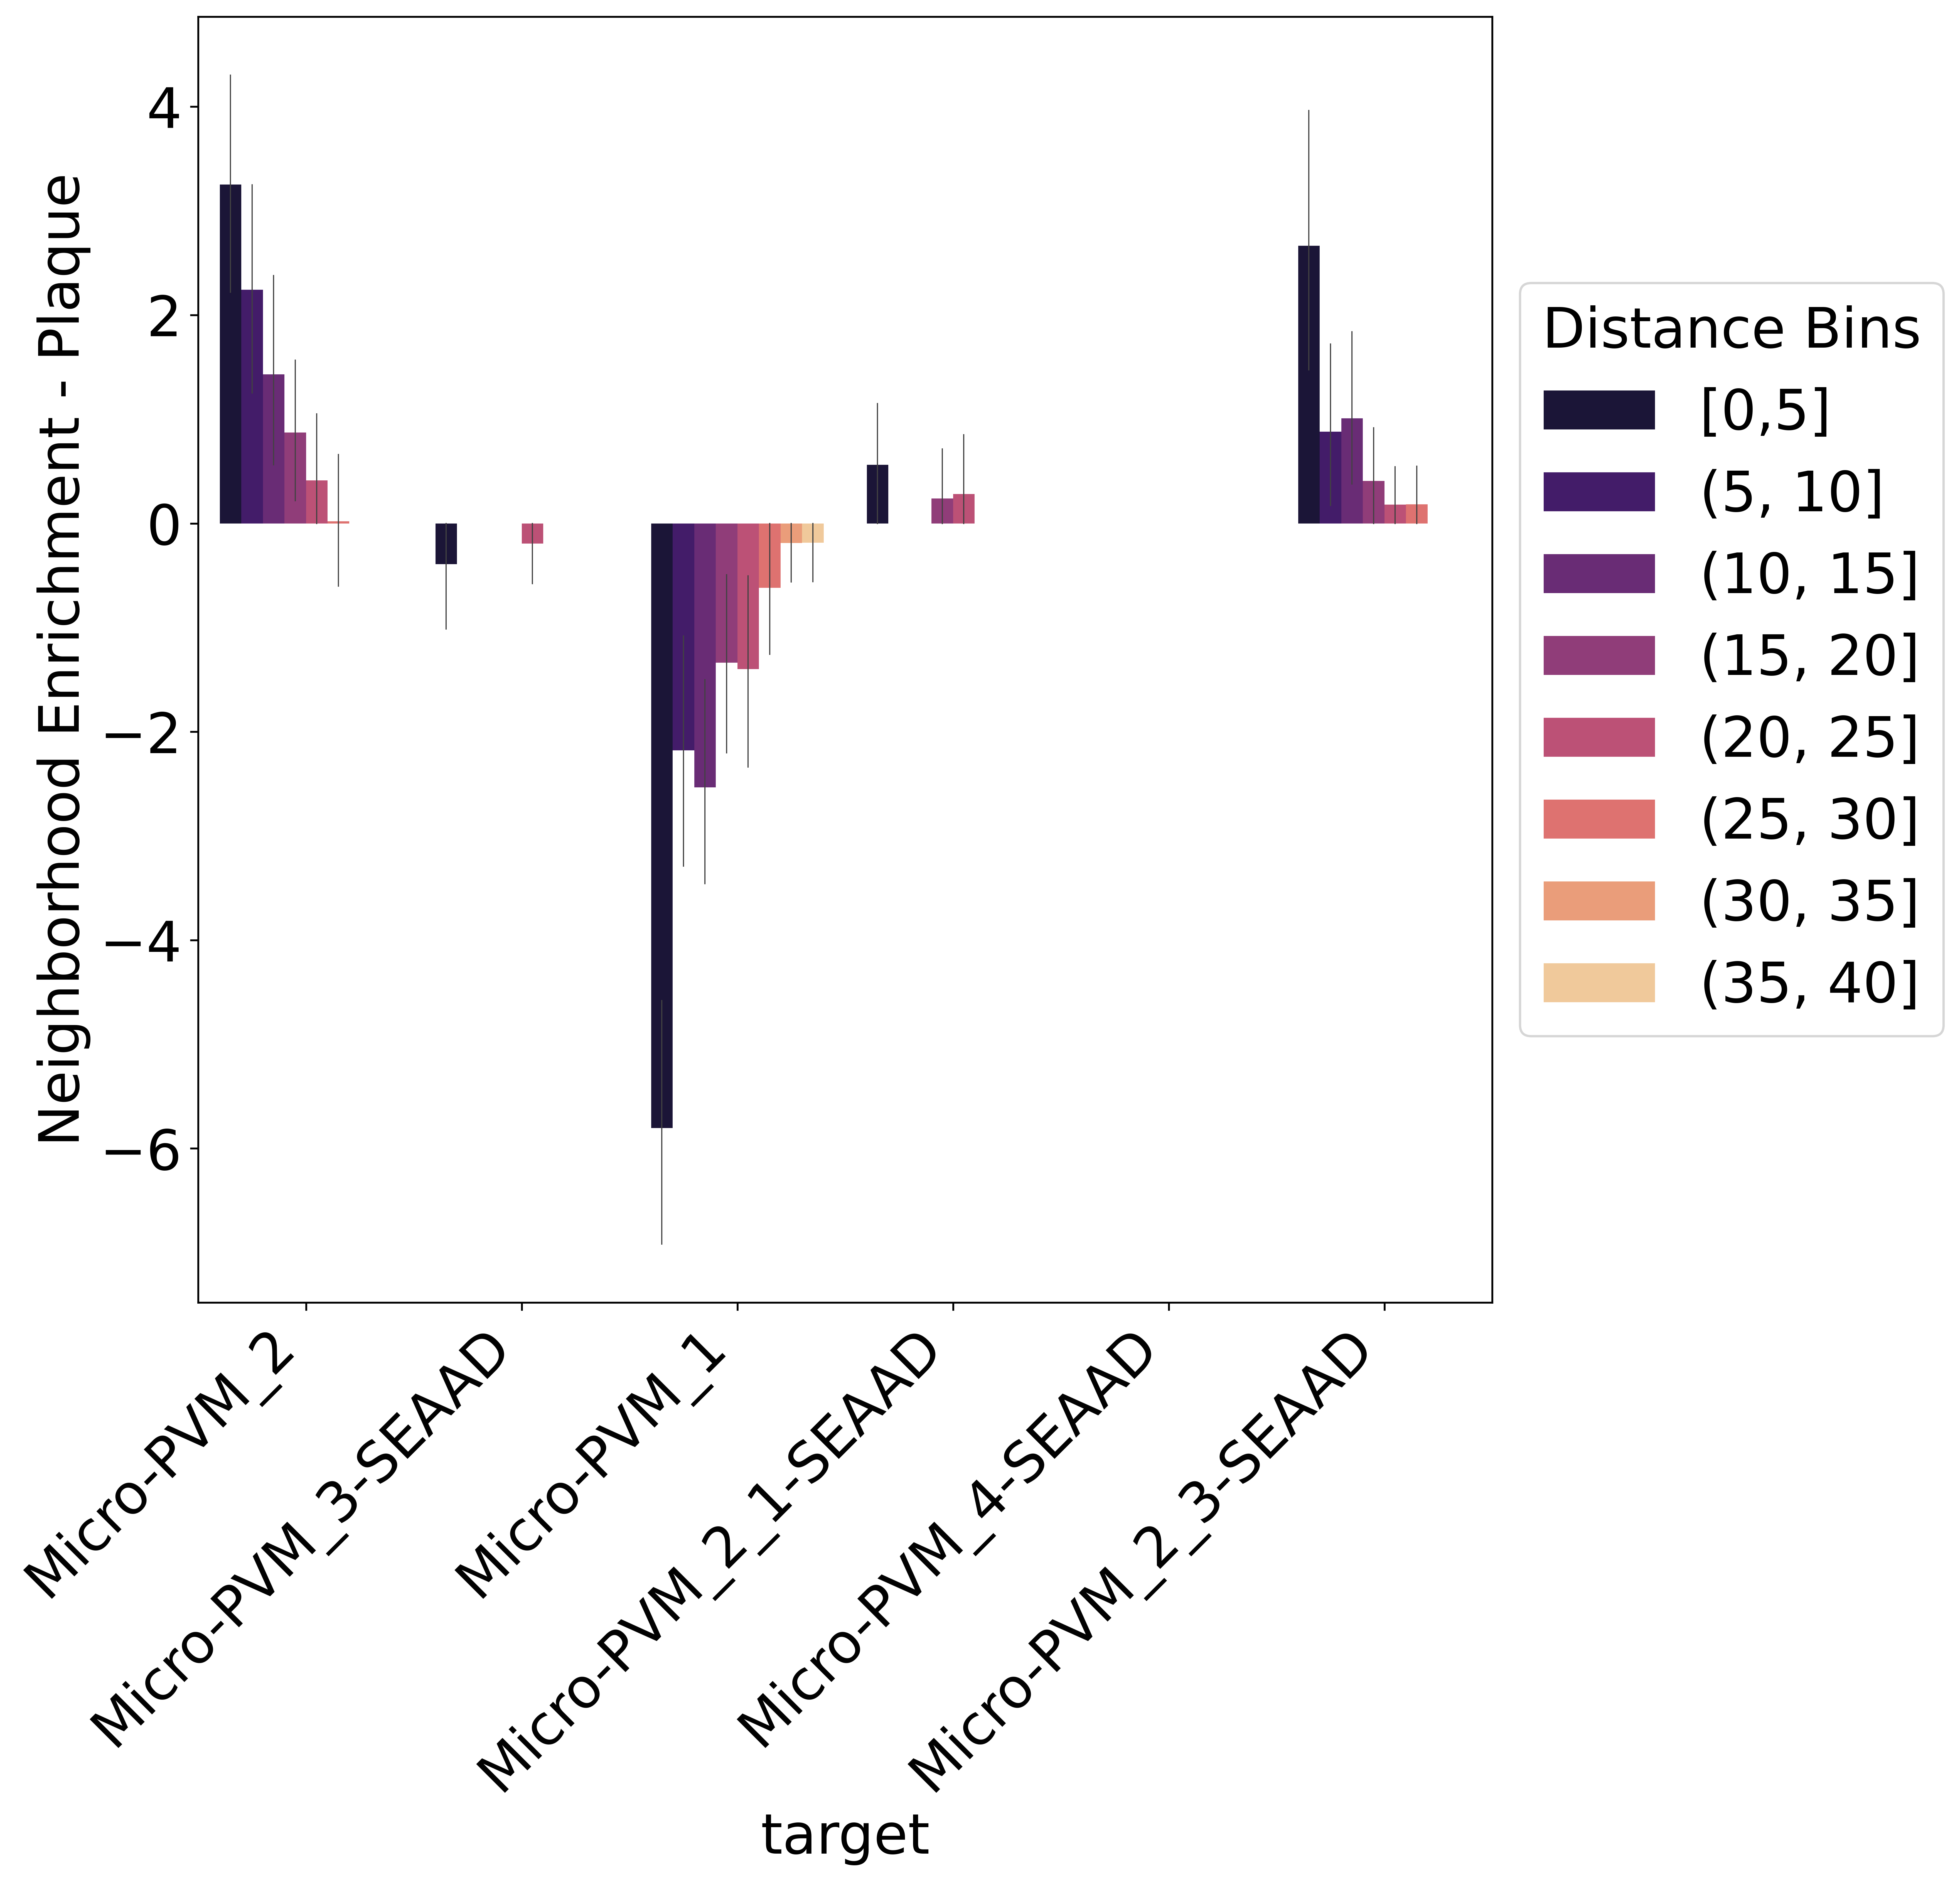

In [80]:
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    sns.barplot(data = df[(df["source"] == "Plaque") & (df["target"].str.startswith("Micro")) & (df['level'] == "Supertype")].sort_values("source"), x = "target", y = "Neighborhood_Enrichment", hue = "Distance Bins",  palette = "magma", hue_order = radius2bin.values(),  err_kws={'linewidth': 0.5})
    # sns.swarmplot(data = df[(df["source"] == "Plaque") & (df["target"].str.startswith("Micro")) & (df['level'] == "Supertype")].sort_values("source"), x = "target", y = "Neighborhood_Enrichment", hue = "Distance Bins",  palette = "magma", hue_order = radius2bin.values(),  err_kws={'linewidth': 0.5})
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", ax = ax, color = "black", s = 6)
    # sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", hue = "radius", ax = ax)
    plt.xticks(rotation = 45, ha='right')
    plt.ylabel("Neighborhood Enrichment - Plaque")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = r"Distance Bins")
    # Set the outline width
    # plt.savefig(
    # f'/scratch/neighborhood_enrichment_plauqe_micro.svg',
    # bbox_inches='tight',
    # )    
    plt.show()

# Cellular Neighborhood enrichment analysis

In [81]:
stat_dir = Path("/data/20251208_neighborhood_enrichment/neighborhood_enrichment/")
dfs  = []
radius2bin = {'5.0':'[0,5]', 
              '10.0':'(5, 10]',
              '15.0':'(10, 15]',
              '20.0':'(15, 20]',
              '25.0':'(20, 25]',
              '30.0':'(25, 30]',
              '35.0':'(30, 35]',
              '40.0':'(35, 40]',
             }
for path in stat_dir.glob("**/neighborhood_stats_*.csv"):
    radius = path.stem.split("_")[-1]
    level = path.stem.split("_")[-4]
    df = pd.read_csv(path).set_index(["source", "target"])
    df["barcode"] = int(path.parent.name.split("_")[0])
    df['radius'] = float(radius)
    df['Distance Bins'] =  radius2bin[radius]
    df["level"] = level
    dfs.append(df)
stat_df = pd.concat(dfs)
stat_df

radius_bins  observed     mean_sim  \
source              target                                                    
Oligodendrocyte     Oligodendrocyte       141.176471      5900  4927.039683   
Ependymal           Ependymal             141.176471       372   192.230159   
                    Sst Chodl             141.176471         2     0.071429   
Sst Chodl           Ependymal             141.176471         2     0.071429   
VLMC                VLMC                  141.176471      1490  1167.373016   
...                                              ...       ...          ...   
SMC-SEAAD           STRv D1 MSN            47.058824         3     2.931548   
Sst Chodl_1         Micro-PVM_2_3-SEAAD    47.058824         4     4.074405   
Micro-PVM_2_3-SEAAD Sst Chodl_1            47.058824         4     4.074405   
VLMC_1              Astro_5                47.058824         3     2.982143   
Astro_5             VLMC_1                 47.058824         3     2.982143   

                                           std_sim         z       p_value  \
source              target                                                   
Oligodendrocyte     Oligodendrocyte      99.231958  9.804909  0.000000e+00   
Ependymal           Ependymal            20.974534  8.570862  0.000000e+00   
                    Sst Chodl             0.268981  7.169921  7.505108e-13   
Sst Chodl           Ependymal             0.268981  7.169921  7.505108e-13   
VLMC                VLMC                 49.734666  6.486964  8.758327e-11   
...                                            ...       ...           ...   
SMC-SEAAD           STRv D1 MSN           1.753498  0.039038  9.688604e-01   
Sst Chodl_1         Micro-PVM_2_3-SEAAD   1.924447 -0.038663  9.691591e-01   
Micro-PVM_2_3-SEAAD Sst Chodl_1           1.924447 -0.038663  9.691591e-01   
VLMC_1              Astro_5               1.690466  0.010563  9.915717e-01   
Astro_5             VLMC_1                1.690466  0.010563  9.915717e-01   

                                          adj_p_value     barcode  radius  \
source              target                                                  
Oligodendrocyte     Oligodendrocyte      0.000000e+00  1417649139    30.0   
Ependymal           Ependymal            0.000000e+00  1417649139    30.0   
                    Sst Chodl            3.339773e-11  1417649139    30.0   
Sst Chodl           Ependymal            3.339773e-11  1417649139    30.0   
VLMC                VLMC                 3.117965e-09  1417649139    30.0   
...                                               ...         ...     ...   
SMC-SEAAD           STRv D1 MSN          9.707558e-01  1417643954    10.0   
Sst Chodl_1         Micro-PVM_2_3-SEAAD  9.707558e-01  1417643954    10.0   
Micro-PVM_2_3-SEAAD Sst Chodl_1          9.707558e-01  1417643954    10.0   
VLMC_1              Astro_5              9.915717e-01  1417643954    10.0   
Astro_5             VLMC_1               9.915717e-01  1417643954    10.0   

                                        Distance Bins      level  
source              target                                        
Oligodendrocyte     Oligodendrocyte          (25, 30]   Subclass  
Ependymal           Ependymal                (25, 30]   Subclass  
                    Sst Chodl                (25, 30]   Subclass  
Sst Chodl           Ependymal                (25, 30]   Subclass  
VLMC                VLMC                     (25, 30]   Subclass  
...                                               ...        ...  
SMC-SEAAD           STRv D1 MSN               (5, 10]  Supertype  
Sst Chodl_1         Micro-PVM_2_3-SEAAD       (5, 10]  Supertype  
Micro-PVM_2_3-SEAAD Sst Chodl_1               (5, 10]  Supertype  
VLMC_1              Astro_5                   (5, 10]  Supertype  
Astro_5             VLMC_1                    (5, 10]  Supertype  

[327550 rows x 11 columns]

In [82]:
stat_df["Neighborhood_Enrichment"] = 0
stat_df = stat_df.reset_index()
stat_df.loc[(stat_df["adj_p_value"] < 0.05), "Neighborhood_Enrichment"] = stat_df.loc[stat_df["adj_p_value"] < 0.05, "z"]

/tmp/ipykernel_45070/1315703484.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[9.80490897 8.57086214 7.16992142 ... 2.56831072 2.56491455 2.56491455]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  stat_df.loc[(stat_df["adj_p_value"] < 0.05), "Neighborhood_Enrichment"] = stat_df.loc[stat_df["adj_p_value"] < 0.05, "z"]


In [83]:
df = stat_df.reset_index()
df = df[~df["source"].isin(cells_to_remove) & ~df["target"].isin(cells_to_remove)]

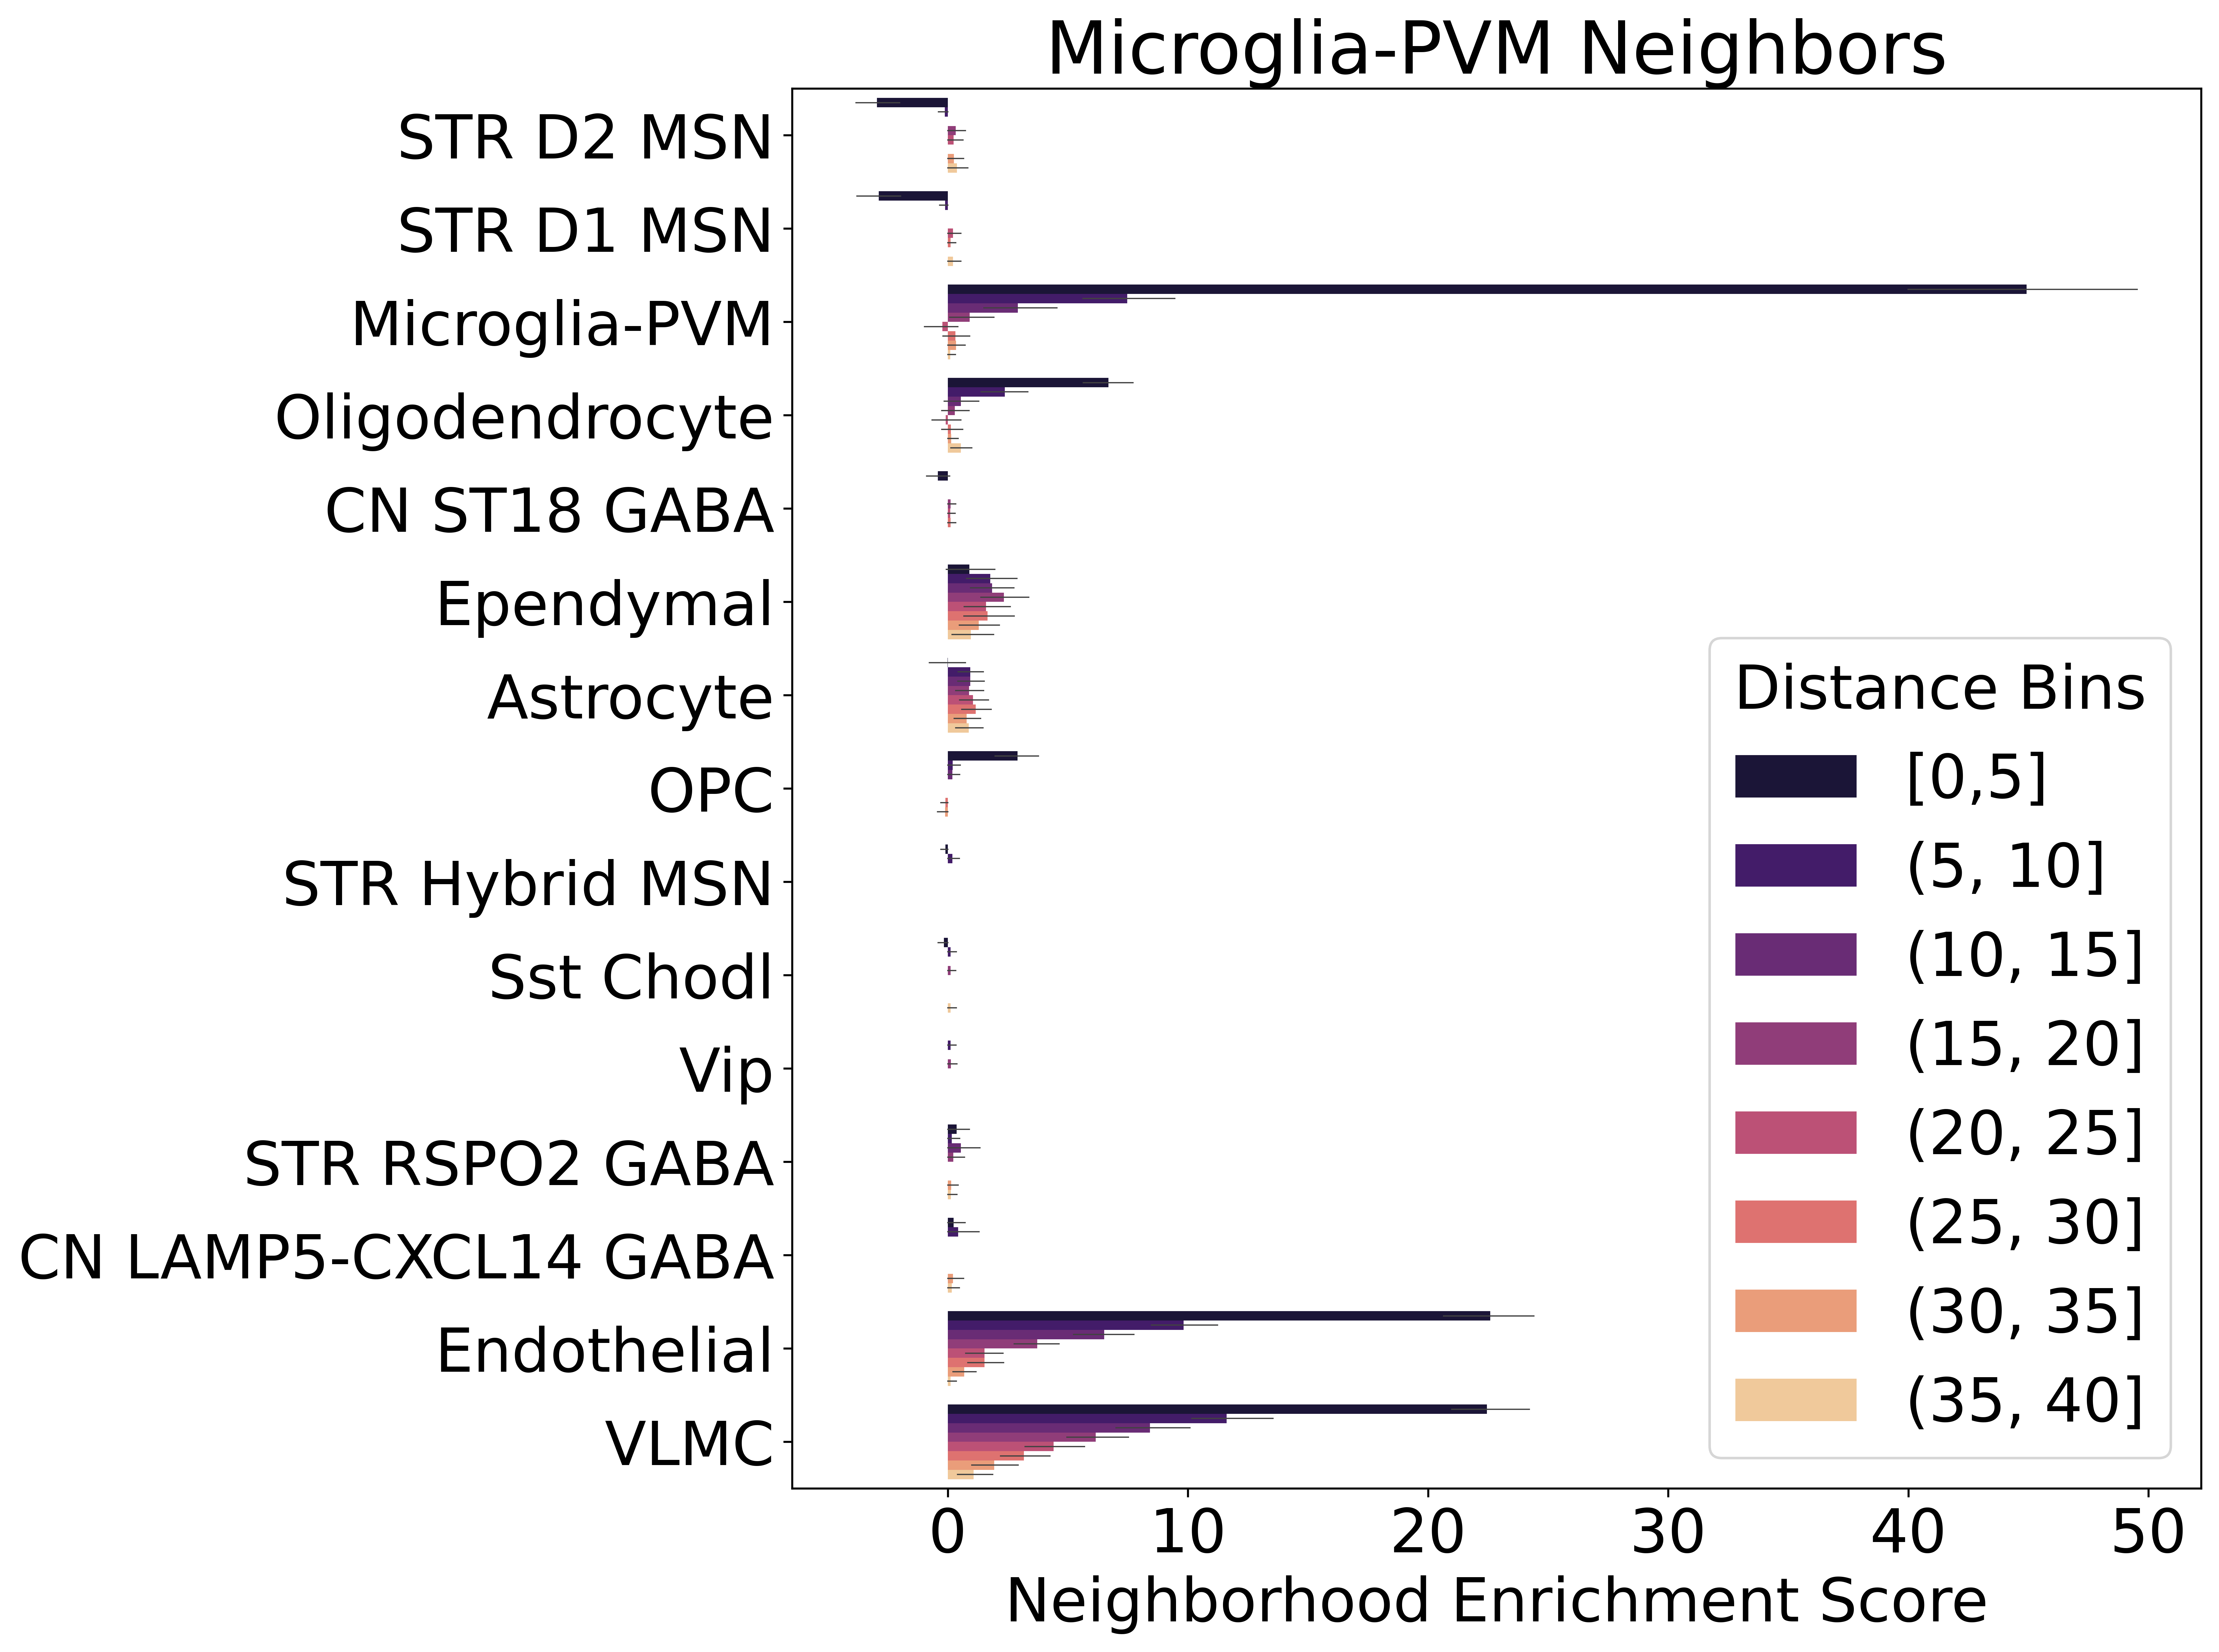

In [84]:
plt.rcParams["font.size"] = 24
fig, ax = plt.subplots(figsize = (10, 10), dpi = 600)
sns.barplot(data = df[(df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")].sort_values("Neighborhood_Enrichment"), y = "target", x = "Neighborhood_Enrichment", hue = "Distance Bins", hue_order = list(radius2bin.values()), ax = ax, palette = "magma",   err_kws={'linewidth': 0.5})
# sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", ax = ax, color = "black", s = 6)
# sns.swarmplot(data = df[ (df["source"] == "Microglia-PVM") & (df["target"] != "Unknown")], y = "target", x = "Neighborhood_Enrichment", hue = "radius", ax = ax)
plt.xlabel("Neighborhood Enrichment Score")
plt.ylabel(None)
plt.title("Microglia-PVM Neighbors")
# plt.savefig(
# f'/scratch/Figure4_neighborhood_enrichment_microglia.svg',
# bbox_inches='tight',
# )    
plt.show()